In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv(
    "../data/raw/merged_1_datetime.csv",
    parse_dates=["DATETIME"],
    decimal=','
)

df.head()

,DATETIME,NO2,SO2,PM25,PM10,CO,O3,TMP,RAIN,HUM,WS,WD
0,2026-07-01 00:00:01,50.64,3.46,6.48,12.80,395.07,3.77,32.76,0.0,73.40,1.52,134
1,2026-07-01 00:00:02,16.43,0.00,40.08,73.72,725.05,13.55,32.72,0.0,72.14,0.05,50
2,2026-07-01 00:00:02,16.43,0.00,40.08,73.72,725.05,13.55,32.28,0.0,72.89,0.76,225
3,2026-07-01 00:00:02,16.43,0.00,40.08,73.72,725.05,13.55,32.73,0.0,65.19,3.26,167
4,2026-07-01 00:00:02,18.87,0.00,18.32,41.00,423.55,55.66,32.72,0.0,72.14,0.05,50


In [26]:
print(df.dtypes)

DATETIME    datetime64[us]
NO2                float64
SO2                float64
PM25               float64
PM10               float64
CO                 float64
O3                 float64
TMP                float64
RAIN               float64
HUM                float64
WS                 float64
WD                   int64
dtype: object


In [27]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

df.info()

Jumlah baris : 324988
Jumlah kolom : 12
<class 'pandas.DataFrame'>
RangeIndex: 324988 entries, 0 to 324987
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   DATETIME  324988 non-null  datetime64[us]
 1   NO2       324988 non-null  float64       
 2   SO2       324988 non-null  float64       
 3   PM25      324988 non-null  float64       
 4   PM10      324988 non-null  float64       
 5   CO        324988 non-null  float64       
 6   O3        324988 non-null  float64       
 7   TMP       324988 non-null  float64       
 8   RAIN      324988 non-null  float64       
 9   HUM       324988 non-null  float64       
 10  WS        324988 non-null  float64       
 11  WD        324988 non-null  int64         
dtypes: datetime64[us](1), float64(10), int64(1)
memory usage: 29.8 MB


In [28]:
df.head()

,DATETIME,NO2,SO2,PM25,PM10,CO,O3,TMP,RAIN,HUM,WS,WD
0,2026-07-01 00:00:01,50.64,3.46,6.48,12.80,395.07,3.77,32.76,0.0,73.40,1.52,134
1,2026-07-01 00:00:02,16.43,0.00,40.08,73.72,725.05,13.55,32.72,0.0,72.14,0.05,50
2,2026-07-01 00:00:02,16.43,0.00,40.08,73.72,725.05,13.55,32.28,0.0,72.89,0.76,225
3,2026-07-01 00:00:02,16.43,0.00,40.08,73.72,725.05,13.55,32.73,0.0,65.19,3.26,167
4,2026-07-01 00:00:02,18.87,0.00,18.32,41.00,423.55,55.66,32.72,0.0,72.14,0.05,50


In [29]:
df.tail()

,DATETIME,NO2,SO2,PM25,PM10,CO,O3,TMP,RAIN,HUM,WS,WD
324983,2026-09-21 17:40:01,0.00,3.93,63.54,113.83,655.43,79.74,34.76,0.0,59.75,1.47,160
324984,2026-09-21 17:40:02,2.65,0.00,55.47,100.90,614.85,57.62,35.06,0.0,64.18,1.13,3
324985,2026-09-21 17:40:02,2.65,0.00,55.47,100.90,614.85,57.62,33.93,0.0,69.73,1.66,132
324986,2026-09-21 17:40:02,38.73,3.72,37.07,63.78,604.05,2.36,35.06,0.0,64.18,1.13,3
324987,2026-09-21 17:40:02,38.73,3.72,37.07,63.78,604.05,2.36,33.93,0.0,69.73,1.66,132


In [30]:
df.columns.tolist()

['DATETIME',
 'NO2',
 'SO2',
 'PM25',
 'PM10',
 'CO',
 'O3',
 'TMP',
 'RAIN',
 'HUM',
 'WS',
 'WD']

In [31]:
print("Data paling awal :", df["DATETIME"].min())
print("Data paling akhir:", df["DATETIME"].max())

Data paling awal : 2026-07-01 00:00:01
Data paling akhir: 2026-09-21 17:40:02


In [32]:
missing = df.isnull().sum()

print(missing)

DATETIME    0
NO2         0
SO2         0
PM25        0
PM10        0
CO          0
O3          0
TMP         0
RAIN        0
HUM         0
WS          0
WD          0
dtype: int64


In [33]:
missing_pct = (df.isnull().sum() / len(df)) * 100

print(missing_pct)

DATETIME    0.0
NO2         0.0
SO2         0.0
PM25        0.0
PM10        0.0
CO          0.0
O3          0.0
TMP         0.0
RAIN        0.0
HUM         0.0
WS          0.0
WD          0.0
dtype: float64


In [34]:
print("Duplicate seluruh baris:", df.duplicated().sum())

Duplicate seluruh baris: 0


In [35]:
print("Jumlah timestamp unik:", df["DATETIME"].nunique())
print("Jumlah seluruh baris :", len(df))

Jumlah timestamp unik: 46333
Jumlah seluruh baris : 324988


In [36]:
timestamp_count = (
    df["DATETIME"]
    .value_counts()
    .sort_index()
)

timestamp_count.head(20)

DATETIME
2026-07-01 00:00:01     1
2026-07-01 00:00:02    12
2026-07-01 00:05:01     4
2026-07-01 00:05:02     9
2026-07-01 00:10:01     9
2026-07-01 00:10:02     4
2026-07-01 00:20:01     1
2026-07-01 00:20:02    16
2026-07-01 00:25:02     4
2026-07-01 00:30:01     1
2026-07-01 00:30:02    12
2026-07-01 00:35:01     9
2026-07-01 00:35:02     4
2026-07-01 00:45:01     1
2026-07-01 00:45:02    16
2026-07-01 00:50:01     1
2026-07-01 00:50:02    12
2026-07-01 00:55:02    25
2026-07-01 01:00:02     5
2026-07-01 01:05:01     1
Name: count, dtype: int64

In [37]:
timestamp_count.describe()

count    46333.000000
mean         7.014180
std          5.738277
min          1.000000
25%          4.000000
50%          4.000000
75%          9.000000
max         25.000000
Name: count, dtype: float64

In [38]:
time_unique = (
    df["DATETIME"]
    .drop_duplicates()
    .sort_values()
)

time_diff = time_unique.diff()

print(time_diff.value_counts().head(20))

DATETIME
0 days 00:00:01    22586
0 days 00:04:59    19183
0 days 00:05:00     2266
0 days 00:04:58     1752
0 days 00:00:02      181
0 days 00:09:59      138
0 days 00:05:01       43
0 days 00:04:57       41
0 days 00:10:00       40
0 days 00:00:03       13
0 days 00:04:56       12
0 days 00:15:00        7
0 days 00:14:59        6
0 days 00:00:13        5
0 days 00:19:59        5
0 days 00:10:01        4
0 days 00:09:58        4
0 days 00:04:49        4
0 days 00:05:02        3
0 days 00:00:04        3
Name: count, dtype: int64


In [39]:
df["DATETIME_5MIN"] = df["DATETIME"].dt.floor("5min")

df[["DATETIME", "DATETIME_5MIN"]].head(20)

,DATETIME,DATETIME_5MIN
0,2026-07-01 00:00:01,2026-07-01 00:00:00
1,2026-07-01 00:00:02,2026-07-01 00:00:00
2,2026-07-01 00:00:02,2026-07-01 00:00:00
3,2026-07-01 00:00:02,2026-07-01 00:00:00
4,2026-07-01 00:00:02,2026-07-01 00:00:00
5,2026-07-01 00:00:02,2026-07-01 00:00:00
6,2026-07-01 00:00:02,2026-07-01 00:00:00
7,2026-07-01 00:00:02,2026-07-01 00:00:00
8,2026-07-01 00:00:02,2026-07-01 00:00:00
9,2026-07-01 00:00:02,2026-07-01 00:00:00


In [40]:
df.groupby("DATETIME_5MIN")["PM25"].agg(
    ["count", "mean", "min", "max"]
).head(20)

,count,mean,min,max
DATETIME_5MIN,,,,
2026-07-01 00:00:00,13,20.727692,6.48,40.08
2026-07-01 00:05:00,13,22.643077,6.53,54.16
2026-07-01 00:10:00,13,17.232308,6.96,35.80
2026-07-01 00:20:00,17,17.289412,7.26,32.04
2026-07-01 00:25:00,4,17.527500,7.67,26.86
2026-07-01 00:30:00,13,19.366154,7.86,37.26
2026-07-01 00:35:00,13,24.936923,8.04,43.09
2026-07-01 00:45:00,17,25.292941,8.93,41.46
2026-07-01 00:50:00,13,21.065385,9.00,48.55


In [41]:
df.groupby("DATETIME_5MIN").size().value_counts().sort_index()

1        55
2        80
3       149
4       124
5       117
6       341
7        88
8       823
9       652
10     1781
11      974
12       32
13    10551
16      458
17     5936
20       96
25     1276
Name: count, dtype: int64

In [42]:
expected_5min = pd.date_range(
    start=df["DATETIME_5MIN"].min(),
    end=df["DATETIME_5MIN"].max(),
    freq="5min"
)

actual_5min = pd.DatetimeIndex(
    df["DATETIME_5MIN"].drop_duplicates().sort_values()
)

missing_5min = expected_5min.difference(actual_5min)

print("Expected 5-menit :", len(expected_5min))
print("Actual 5-menit   :", len(actual_5min))
print("Missing 5-menit  :", len(missing_5min))

Expected 5-menit : 23829
Actual 5-menit   : 23533
Missing 5-menit  : 296


In [43]:
missing_diff = missing_5min.to_series().diff()

missing_diff.value_counts().head(20)

0 days 00:05:00    84
0 days 00:10:00    36
0 days 00:20:00    13
0 days 00:25:00    11
0 days 00:15:00    10
0 days 00:30:00     9
0 days 00:35:00     5
0 days 03:00:00     4
0 days 07:20:00     3
0 days 01:35:00     3
0 days 02:00:00     3
0 days 12:00:00     3
0 days 01:00:00     3
0 days 02:40:00     3
0 days 00:45:00     2
0 days 00:55:00     2
0 days 07:00:00     2
0 days 01:45:00     2
0 days 01:20:00     2
0 days 02:20:00     2
Name: count, dtype: int64

In [44]:
missing_groups = (
    missing_5min.to_series()
    .diff()
    .ne(pd.Timedelta("5min"))
    .cumsum()
)

gap_length = missing_5min.to_series().groupby(missing_groups).size()

gap_length.value_counts().sort_index()

1     186
2      14
3       9
5       1
6       1
44      1
Name: count, dtype: int64

In [45]:
gap_44 = missing_5min[
    missing_5min.to_series()
    .diff()
    .ne(pd.Timedelta("5min"))
    .cumsum()
    .eq(
        missing_5min.to_series()
        .diff()
        .ne(pd.Timedelta("5min"))
        .cumsum()
        .value_counts()
        .idxmax()
    )
]

print(gap_44)

DatetimeIndex(['2026-08-05 15:50:00', '2026-08-05 15:55:00',
               '2026-08-05 16:00:00', '2026-08-05 16:05:00',
               '2026-08-05 16:10:00', '2026-08-05 16:15:00',
               '2026-08-05 16:20:00', '2026-08-05 16:25:00',
               '2026-08-05 16:30:00', '2026-08-05 16:35:00',
               '2026-08-05 16:40:00', '2026-08-05 16:45:00',
               '2026-08-05 16:50:00', '2026-08-05 16:55:00',
               '2026-08-05 17:00:00', '2026-08-05 17:05:00',
               '2026-08-05 17:10:00', '2026-08-05 17:15:00',
               '2026-08-05 17:20:00', '2026-08-05 17:25:00',
               '2026-08-05 17:30:00', '2026-08-05 17:35:00',
               '2026-08-05 17:40:00', '2026-08-05 17:45:00',
               '2026-08-05 17:50:00', '2026-08-05 17:55:00',
               '2026-08-05 18:00:00', '2026-08-05 18:05:00',
               '2026-08-05 18:10:00', '2026-08-05 18:15:00',
               '2026-08-05 18:20:00', '2026-08-05 18:25:00',
               '2026-08-

In [46]:
missing_groups = (
    missing_5min.to_series()
    .diff()
    .ne(pd.Timedelta("5min"))
    .cumsum()
)

gap_length = missing_5min.to_series().groupby(missing_groups).size()

long_gaps = gap_length[gap_length >= 10]

print(long_gaps)

97    44
dtype: int64


In [47]:
for group_id in long_gaps.index:
    print(
        missing_5min[
            missing_groups == group_id
        ].min(),
        "sampai",
        missing_5min[
            missing_groups == group_id
        ].max()
    )

2026-08-05 15:50:00 sampai 2026-08-05 19:25:00


In [48]:
df_5min = df.copy()

df_5min["DATETIME"] = df_5min["DATETIME"].dt.floor("5min")

df_5min = df_5min.sort_values("DATETIME")

df_5min.head()

,DATETIME,NO2,SO2,PM25,PM10,CO,O3,TMP,RAIN,HUM,WS,WD,DATETIME_5MIN
0,2026-07-01,50.64,3.46,6.48,12.80,395.07,3.77,32.76,0.0,73.40,1.52,134,2026-07-01
12,2026-07-01,4.27,3.80,12.58,29.57,436.74,27.58,32.73,0.0,65.19,3.26,167,2026-07-01
11,2026-07-01,4.27,3.80,12.58,29.57,436.74,27.58,32.28,0.0,72.89,0.76,225,2026-07-01
10,2026-07-01,4.27,3.80,12.58,29.57,436.74,27.58,32.72,0.0,72.14,0.05,50,2026-07-01
8,2026-07-01,6.85,0.00,16.68,36.08,366.62,2.26,32.28,0.0,72.89,0.76,225,2026-07-01


In [49]:
df_5min_agg = (
    df_5min
    .groupby("DATETIME")
    .agg({
        "NO2": "mean",
        "SO2": "mean",
        "PM25": "mean",
        "PM10": "mean",
        "TMP": "mean",
        "HUM": "mean",
        "WS": "mean"
    })
    .reset_index()
)

df_5min_agg.head()

,DATETIME,NO2,SO2,PM25,PM10,TMP,HUM,WS
0,2026-07-01 00:00:00,14.607692,1.143077,20.727692,42.608462,32.590769,70.329231,1.369231
1,2026-07-01 00:05:00,18.420769,1.151538,22.643077,44.743846,32.315385,72.180769,1.618462
2,2026-07-01 00:10:00,18.908462,1.922308,17.232308,36.014615,32.174615,72.046923,2.154615
3,2026-07-01 00:20:00,14.212353,2.244706,17.289412,35.922353,31.672941,73.311176,1.960588
4,2026-07-01 00:25:00,13.285000,1.722500,17.527500,36.920000,31.040000,75.240000,0.000000


In [50]:
df_5min["RAIN"].describe()

count    324988.000000
mean          0.000175
std           0.005281
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.460000
Name: RAIN, dtype: float64

In [51]:
df_5min.loc[df_5min["RAIN"] > 0, ["DATETIME", "RAIN"]].head(20)

,DATETIME,RAIN
1372,2026-07-01 08:40:00,0.01
1374,2026-07-01 08:40:00,0.01
1375,2026-07-01 08:40:00,0.02
1377,2026-07-01 08:40:00,0.02
1379,2026-07-01 08:40:00,0.02
1390,2026-07-01 08:50:00,0.02
1391,2026-07-01 08:50:00,0.01
1388,2026-07-01 08:50:00,0.01
1387,2026-07-01 08:50:00,0.02
1385,2026-07-01 08:50:00,0.01


In [53]:
print(df_5min_agg.columns.tolist())
print("\nShape:", df_5min_agg.shape)
print("\n5 baris pertama:")
print(df_5min_agg.head())

['DATETIME', 'NO2', 'SO2', 'PM25', 'PM10', 'TMP', 'HUM', 'WS']

Shape: (23533, 8)

5 baris pertama:
             DATETIME        NO2       SO2       PM25       PM10        TMP  \
0 2026-07-01 00:00:00  14.607692  1.143077  20.727692  42.608462  32.590769   
1 2026-07-01 00:05:00  18.420769  1.151538  22.643077  44.743846  32.315385   
2 2026-07-01 00:10:00  18.908462  1.922308  17.232308  36.014615  32.174615   
3 2026-07-01 00:20:00  14.212353  2.244706  17.289412  35.922353  31.672941   
4 2026-07-01 00:25:00  13.285000  1.722500  17.527500  36.920000  31.040000   

         HUM        WS  
0  70.329231  1.369231  
1  72.180769  1.618462  
2  72.046923  2.154615  
3  73.311176  1.960588  
4  75.240000  0.000000  


In [55]:
df_5min_agg=df_5min_agg.rename(
    columns={"DATETIME": "DATETIME_5MIN"}
)
print("Jumlah baris hasil agregasi :", len(df_5min_agg))
print("Periode awal :", df_5min_agg["DATETIME_5MIN"].min())
print("Periode akhir:", df_5min_agg["DATETIME_5MIN"].max())

print("\nJumlah missing value:")
print(df_5min_agg.isnull().sum())

Jumlah baris hasil agregasi : 23533
Periode awal : 2026-07-01 00:00:00
Periode akhir: 2026-09-21 17:40:00

Jumlah missing value:
DATETIME_5MIN    0
NO2              0
SO2              0
PM25             0
PM10             0
TMP              0
HUM              0
WS               0
dtype: int64


In [56]:
df_5min_agg = (
    df_5min
    .groupby("DATETIME_5MIN")
    .agg({
        "NO2": "mean",
        "SO2": "mean",
        "PM25": "mean",
        "PM10": "mean",
        "CO": "mean",
        "O3": "mean",
        "TMP": "mean",
        "HUM": "mean",
        "WS": "mean"
    })
    .reset_index()
)

print("Shape:", df_5min_agg.shape)

print("\nKolom:")
print(df_5min_agg.columns.tolist())

print("\nMissing value:")
print(df_5min_agg.isnull().sum())

Shape: (23533, 10)

Kolom:
['DATETIME_5MIN', 'NO2', 'SO2', 'PM25', 'PM10', 'CO', 'O3', 'TMP', 'HUM', 'WS']

Missing value:
DATETIME_5MIN    0
NO2              0
SO2              0
PM25             0
PM10             0
CO               0
O3               0
TMP              0
HUM              0
WS               0
dtype: int64


In [57]:
hourly_count = (
    df_5min_agg
    .set_index("DATETIME_5MIN")
    .resample("1h")
    .size()
)

print(hourly_count.describe())

print("\nDistribusi jumlah interval 5-menit per jam:")
print(hourly_count.value_counts().sort_index())

count    1986.000000
mean       11.849446
std         0.762465
min         0.000000
25%        12.000000
50%        12.000000
75%        12.000000
max        12.000000
dtype: float64

Distribusi jumlah interval 5-menit per jam:
0        3
2        1
3        1
4        1
6        3
7        1
8        4
9       12
10      28
11     105
12    1827
Name: count, dtype: int64


In [58]:
df_hourly = (
    df_5min_agg
    .set_index("DATETIME_5MIN")
    .resample("1h")
    .mean()
    .reset_index()
)

df_hourly.head(10)
print("Shape:", df_hourly.shape)

print("\nKolom:")
print(df_hourly.columns.tolist())

print("\nMissing values:")
print(df_hourly.isna().sum())

Shape: (1986, 10)

Kolom:
['DATETIME_5MIN', 'NO2', 'SO2', 'PM25', 'PM10', 'CO', 'O3', 'TMP', 'HUM', 'WS']

Missing values:
DATETIME_5MIN    0
NO2              3
SO2              3
PM25             3
PM10             3
CO               3
O3               3
TMP              3
HUM              3
WS               3
dtype: int64


In [60]:
print(
    df_hourly[
        ["PM25", "PM10", "CO", "O3", "SO2", "NO2"]
    ].describe()
)

              PM25         PM10           CO           O3          SO2  \
count  1983.000000  1983.000000  1983.000000  1983.000000  1983.000000   
mean     32.682595    67.502484   500.007855    22.912742     2.060356   
std      21.513372    41.189613   183.572302    12.024498     1.975212   
min       7.904024    20.117115   298.091315     2.823424     0.000000   
25%      18.321341    39.328915   404.716243    13.190190     1.462215   
50%      26.485206    55.882112   436.059612    18.760586     1.686722   
75%      39.332539    80.925309   504.011077    33.147464     1.922083   
max     173.929236   352.002280  1988.284075    61.465529    27.677345   

               NO2  
count  1983.000000  
mean     23.093431  
std       9.530820  
min       0.181417  
25%      13.629727  
50%      24.862014  
75%      30.248884  
max      47.499436  


In [61]:
pollutant_cols = [
    "PM25",
    "PM10",
    "CO",
    "O3",
    "SO2",
    "NO2"
]

print("Jumlah nilai <= 0:")
print((df_hourly[pollutant_cols] <= 0).sum())

print("\nJumlah nilai negatif:")
print((df_hourly[pollutant_cols] < 0).sum())

Jumlah nilai <= 0:
PM25    0
PM10    0
CO      0
O3      0
SO2     4
NO2     0
dtype: int64

Jumlah nilai negatif:
PM25    0
PM10    0
CO      0
O3      0
SO2     0
NO2     0
dtype: int64


In [62]:
pollutant_cols = [
    "PM25",
    "PM10",
    "CO",
    "O3",
    "SO2",
    "NO2"
]

lags = [1, 2, 3, 6, 24]

for col in pollutant_cols:
    for lag in lags:
        df_hourly[f"{col}_lag_{lag}"] = df_hourly[col].shift(lag)

print("Shape:", df_hourly.shape)

print("\nKolom lag:")
print([
    col for col in df_hourly.columns
    if "_lag_" in col
])

Shape: (1986, 40)

Kolom lag:
['PM25_lag_1', 'PM25_lag_2', 'PM25_lag_3', 'PM25_lag_6', 'PM25_lag_24', 'PM10_lag_1', 'PM10_lag_2', 'PM10_lag_3', 'PM10_lag_6', 'PM10_lag_24', 'CO_lag_1', 'CO_lag_2', 'CO_lag_3', 'CO_lag_6', 'CO_lag_24', 'O3_lag_1', 'O3_lag_2', 'O3_lag_3', 'O3_lag_6', 'O3_lag_24', 'SO2_lag_1', 'SO2_lag_2', 'SO2_lag_3', 'SO2_lag_6', 'SO2_lag_24', 'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3', 'NO2_lag_6', 'NO2_lag_24']


In [63]:
for col in pollutant_cols:
    df_hourly[f"{col}_roll_mean_3"] = (
        df_hourly[col].rolling(window=3).mean()
    )
    
    df_hourly[f"{col}_roll_mean_6"] = (
        df_hourly[col].rolling(window=6).mean()
    )

print("Shape:", df_hourly.shape)

print("\nContoh fitur rolling:")
print(
    df_hourly[
        [
            "DATETIME_5MIN",
            "PM25_roll_mean_3",
            "PM25_roll_mean_6",
            "PM10_roll_mean_3",
            "PM10_roll_mean_6",
            "CO_roll_mean_3",
            "CO_roll_mean_6",
            "O3_roll_mean_3",
            "O3_roll_mean_6",
            "SO2_roll_mean_3",
            "SO2_roll_mean_6",
            "NO2_roll_mean_3",
            "NO2_roll_mean_6"
        ]
    ].tail()
)

Shape: (1986, 52)

Contoh fitur rolling:
           DATETIME_5MIN  PM25_roll_mean_3  PM25_roll_mean_6  \
1981 2026-09-21 13:00:00        125.226863         97.903556   
1982 2026-09-21 14:00:00        125.005787        108.842277   
1983 2026-09-21 15:00:00        115.595805        114.613171   
1984 2026-09-21 16:00:00         98.431871        111.829367   
1985 2026-09-21 17:00:00         75.854881        100.430334   

      PM10_roll_mean_3  PM10_roll_mean_6  CO_roll_mean_3  CO_roll_mean_6  \
1981        232.991270        185.256784     1397.674170     1069.884361   
1982        232.019284        204.229619     1413.194694     1200.321022   
1983        213.569100        213.290468     1382.903601     1313.408567   
1984        179.971981        206.481625     1243.720271     1320.697221   
1985        136.705801        184.362543      988.256271     1200.725483   

      O3_roll_mean_3  O3_roll_mean_6  SO2_roll_mean_3  SO2_roll_mean_6  \
1981        7.371431        9.590116       

In [64]:
# Fitur waktu
df_hourly["hour"] = df_hourly["DATETIME_5MIN"].dt.hour
df_hourly["day_of_week"] = df_hourly["DATETIME_5MIN"].dt.dayofweek

# Representasi siklikal untuk jam
df_hourly["hour_sin"] = np.sin(
    2 * np.pi * df_hourly["hour"] / 24
)

df_hourly["hour_cos"] = np.cos(
    2 * np.pi * df_hourly["hour"] / 24
)

print("Shape:", df_hourly.shape)

print("\nContoh fitur waktu:")
print(
    df_hourly[
        [
            "DATETIME_5MIN",
            "hour",
            "day_of_week",
            "hour_sin",
            "hour_cos"
        ]
    ].tail()
)

Shape: (1986, 56)

Contoh fitur waktu:
           DATETIME_5MIN  hour  day_of_week  hour_sin  hour_cos
1981 2026-09-21 13:00:00    13            0 -0.258819 -0.965926
1982 2026-09-21 14:00:00    14            0 -0.500000 -0.866025
1983 2026-09-21 15:00:00    15            0 -0.707107 -0.707107
1984 2026-09-21 16:00:00    16            0 -0.866025 -0.500000
1985 2026-09-21 17:00:00    17            0 -0.965926 -0.258819


In [65]:
# Ubah arah angin (WD) menjadi fitur siklikal
df["WD_sin"] = np.sin(np.deg2rad(df["WD"]))
df["WD_cos"] = np.cos(np.deg2rad(df["WD"]))

# Agregasi arah angin ke level hourly
wd_hourly = (
    df.set_index("DATETIME")
      .resample("1h")[["WD_sin", "WD_cos"]]
      .mean()
      .reset_index()
)

# Gabungkan ke dataset hourly
df_hourly = df_hourly.merge(
    wd_hourly,
    left_on="DATETIME_5MIN",
    right_on="DATETIME",
    how="left"
).drop(columns=["DATETIME"])

print("Shape:", df_hourly.shape)

print("\nContoh fitur arah angin:")
print(
    df_hourly[
        [
            "DATETIME_5MIN",
            "WD_sin",
            "WD_cos"
        ]
    ].tail()
)

Shape: (1986, 58)

Contoh fitur arah angin:
           DATETIME_5MIN    WD_sin    WD_cos
1981 2026-09-21 13:00:00  0.144908  0.322530
1982 2026-09-21 14:00:00  0.073840  0.122204
1983 2026-09-21 15:00:00  0.234332  0.379937
1984 2026-09-21 16:00:00  0.206040 -0.293367
1985 2026-09-21 17:00:00  0.361967 -0.134220


In [66]:
# Daftar fitur yang akan digunakan bersama
base_features = [
    "TMP",
    "HUM",
    "WS",
    "WD_sin",
    "WD_cos",
    "hour",
    "day_of_week",
    "hour_sin",
    "hour_cos"
]

# Cek apakah semua fitur tersedia
missing_features = [
    col for col in base_features
    if col not in df_hourly.columns
]

print("Fitur yang dicek:")
print(base_features)

print("\nFitur yang belum tersedia:")
print(missing_features)

print("\nJumlah kolom df_hourly:", len(df_hourly.columns))

Fitur yang dicek:
['TMP', 'HUM', 'WS', 'WD_sin', 'WD_cos', 'hour', 'day_of_week', 'hour_sin', 'hour_cos']

Fitur yang belum tersedia:
[]

Jumlah kolom df_hourly: 58


In [59]:
print("Jumlah baris hourly:", len(df_hourly))

print("\nMissing value per kolom:")
print(df_hourly.isnull().sum())

Jumlah baris hourly: 1986

Missing value per kolom:
DATETIME_5MIN    0
NO2              3
SO2              3
PM25             3
PM10             3
CO               3
O3               3
TMP              3
HUM              3
WS               3
dtype: int64


In [37]:
df_hourly.loc[
    df_hourly["PM25"].isna(),
    "DATETIME_5MIN"
]

856   2026-08-05 16:00:00
857   2026-08-05 17:00:00
858   2026-08-05 18:00:00
Name: DATETIME_5MIN, dtype: datetime64[us]

In [38]:
df_hourly.loc[
    850:863,
    ["DATETIME_5MIN", "PM25"]
]

,DATETIME_5MIN,PM25
850,2026-08-05 10:00:00,40.626698
851,2026-08-05 11:00:00,35.032447
852,2026-08-05 12:00:00,38.297164
853,2026-08-05 13:00:00,38.815846
854,2026-08-05 14:00:00,31.758292
855,2026-08-05 15:00:00,24.914571
856,2026-08-05 16:00:00,NaN
857,2026-08-05 17:00:00,NaN
858,2026-08-05 18:00:00,NaN
859,2026-08-05 19:00:00,17.202783


In [39]:
df_hourly["PM25"].describe()

count    1983.000000
mean       32.682595
std        21.513372
min         7.904024
25%        18.321341
50%        26.485206
75%        39.332539
max       173.929236
Name: PM25, dtype: float64

In [40]:
print("PM25 <= 0:", (df_hourly["PM25"] <= 0).sum())
print("PM25 < 0 :", (df_hourly["PM25"] < 0).sum())

PM25 <= 0: 0
PM25 < 0 : 0


In [41]:
df_model = df_hourly.copy()

for lag in [1, 2, 3, 6, 24]:
    df_model[f"PM25_lag_{lag}"] = df_model["PM25"].shift(lag)

df_model[[
    "DATETIME_5MIN",
    "PM25",
    "PM25_lag_1",
    "PM25_lag_2",
    "PM25_lag_3",
    "PM25_lag_6",
    "PM25_lag_24"
]].head(30)

,DATETIME_5MIN,PM25,PM25_lag_1,PM25_lag_2,PM25_lag_3,PM25_lag_6,PM25_lag_24
0,2026-07-01 00:00:00,21.268739,NaN,NaN,NaN,NaN,NaN
1,2026-07-01 01:00:00,23.089072,21.268739,NaN,NaN,NaN,NaN
2,2026-07-01 02:00:00,18.582015,23.089072,21.268739,NaN,NaN,NaN
3,2026-07-01 03:00:00,15.844247,18.582015,23.089072,21.268739,NaN,NaN
4,2026-07-01 04:00:00,16.675103,15.844247,18.582015,23.089072,NaN,NaN
5,2026-07-01 05:00:00,17.227797,16.675103,15.844247,18.582015,NaN,NaN
6,2026-07-01 06:00:00,16.217386,17.227797,16.675103,15.844247,21.268739,NaN
7,2026-07-01 07:00:00,14.964856,16.217386,17.227797,16.675103,23.089072,NaN
8,2026-07-01 08:00:00,13.030133,14.964856,16.217386,17.227797,18.582015,NaN
9,2026-07-01 09:00:00,19.579156,13.030133,14.964856,16.217386,15.844247,NaN


In [42]:
df_model["target"] = df_model["PM25"].shift(-1)

df_model[[
    "DATETIME_5MIN",
    "PM25",
    "PM25_lag_1",
    "PM25_lag_24",
    "target"
]].head(30)

,DATETIME_5MIN,PM25,PM25_lag_1,PM25_lag_24,target
0,2026-07-01 00:00:00,21.268739,NaN,NaN,23.089072
1,2026-07-01 01:00:00,23.089072,21.268739,NaN,18.582015
2,2026-07-01 02:00:00,18.582015,23.089072,NaN,15.844247
3,2026-07-01 03:00:00,15.844247,18.582015,NaN,16.675103
4,2026-07-01 04:00:00,16.675103,15.844247,NaN,17.227797
5,2026-07-01 05:00:00,17.227797,16.675103,NaN,16.217386
6,2026-07-01 06:00:00,16.217386,17.227797,NaN,14.964856
7,2026-07-01 07:00:00,14.964856,16.217386,NaN,13.030133
8,2026-07-01 08:00:00,13.030133,14.964856,NaN,19.579156
9,2026-07-01 09:00:00,19.579156,13.030133,NaN,15.701987


In [43]:
df_model["PM25_roll_mean_3"] = (
    df_model["PM25"]
    .rolling(window=3)
    .mean()
)

df_model["PM25_roll_mean_6"] = (
    df_model["PM25"]
    .rolling(window=6)
    .mean()
)

df_model[[
    "DATETIME_5MIN",
    "PM25",
    "PM25_roll_mean_3",
    "PM25_roll_mean_6"
]].head(10)

,DATETIME_5MIN,PM25,PM25_roll_mean_3,PM25_roll_mean_6
0,2026-07-01 00:00:00,21.268739,NaN,NaN
1,2026-07-01 01:00:00,23.089072,NaN,NaN
2,2026-07-01 02:00:00,18.582015,20.979942,NaN
3,2026-07-01 03:00:00,15.844247,19.171778,NaN
4,2026-07-01 04:00:00,16.675103,17.033788,NaN
5,2026-07-01 05:00:00,17.227797,16.582382,18.781162
6,2026-07-01 06:00:00,16.217386,16.706762,17.939270
7,2026-07-01 07:00:00,14.964856,16.136680,16.585234
8,2026-07-01 08:00:00,13.030133,14.737459,15.659921
9,2026-07-01 09:00:00,19.579156,15.858049,16.282405


In [44]:
df_model["hour"] = df_model["DATETIME_5MIN"].dt.hour
df_model["day_of_week"] = df_model["DATETIME_5MIN"].dt.dayofweek

df_model[[
    "DATETIME_5MIN",
    "hour",
    "day_of_week"
]].head(30)

,DATETIME_5MIN,hour,day_of_week
0,2026-07-01 00:00:00,0,2
1,2026-07-01 01:00:00,1,2
2,2026-07-01 02:00:00,2,2
3,2026-07-01 03:00:00,3,2
4,2026-07-01 04:00:00,4,2
5,2026-07-01 05:00:00,5,2
6,2026-07-01 06:00:00,6,2
7,2026-07-01 07:00:00,7,2
8,2026-07-01 08:00:00,8,2
9,2026-07-01 09:00:00,9,2


In [45]:
df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

df_model[[
    "DATETIME_5MIN",
    "hour",
    "hour_sin",
    "hour_cos"
]].head(25)

,DATETIME_5MIN,hour,hour_sin,hour_cos
0,2026-07-01 00:00:00,0,0.000000e+00,1.000000e+00
1,2026-07-01 01:00:00,1,2.588190e-01,9.659258e-01
2,2026-07-01 02:00:00,2,5.000000e-01,8.660254e-01
3,2026-07-01 03:00:00,3,7.071068e-01,7.071068e-01
4,2026-07-01 04:00:00,4,8.660254e-01,5.000000e-01
5,2026-07-01 05:00:00,5,9.659258e-01,2.588190e-01
6,2026-07-01 06:00:00,6,1.000000e+00,6.123234e-17
7,2026-07-01 07:00:00,7,9.659258e-01,-2.588190e-01
8,2026-07-01 08:00:00,8,8.660254e-01,-5.000000e-01
9,2026-07-01 09:00:00,9,7.071068e-01,-7.071068e-01


In [46]:
df_model.isnull().sum()

DATETIME_5MIN        0
NO2                  3
SO2                  3
PM25                 3
PM10                 3
TMP                  3
HUM                  3
WS                   3
PM25_lag_1           4
PM25_lag_2           5
PM25_lag_3           6
PM25_lag_6           9
PM25_lag_24         27
target               4
PM25_roll_mean_3     7
PM25_roll_mean_6    13
hour                 0
day_of_week          0
hour_sin             0
hour_cos             0
dtype: int64

In [47]:
df_model[[
    "DATETIME_5MIN",
    "PM25",
    "PM10",
    "NO2",
    "SO2",
    "TMP",
    "HUM",
    "WS"
]].head(10)

,DATETIME_5MIN,PM25,PM10,NO2,SO2,TMP,HUM,WS
0,2026-07-01 00:00:00,21.268739,43.914076,16.892766,1.547236,31.764029,73.537033,1.420197
1,2026-07-01 01:00:00,23.089072,47.641170,20.026875,1.206058,30.734312,76.818837,1.423762
2,2026-07-01 02:00:00,18.582015,40.324981,23.489118,1.292720,29.748591,78.965175,1.209339
3,2026-07-01 03:00:00,15.844247,35.921184,30.437735,1.394721,29.124881,81.594595,1.079078
4,2026-07-01 04:00:00,16.675103,38.658588,29.368779,1.239829,28.753726,83.183200,1.065032
5,2026-07-01 05:00:00,17.227797,38.810257,26.794843,1.284130,28.539804,83.980591,1.208154
6,2026-07-01 06:00:00,16.217386,35.728768,24.742640,1.660815,28.520356,83.396788,1.143117
7,2026-07-01 07:00:00,14.964856,33.128638,20.731688,1.742382,28.273563,83.593319,1.235343
8,2026-07-01 08:00:00,13.030133,29.251569,20.055231,1.804371,27.709158,85.202966,1.402832
9,2026-07-01 09:00:00,19.579156,40.575090,19.353150,2.070735,26.804711,86.747281,0.835116


In [48]:
df_5min["WD"].describe()

count    324988.000000
mean        140.035337
std          85.937202
min           0.000000
25%          71.000000
50%         142.000000
75%         205.000000
max         359.000000
Name: WD, dtype: float64

In [49]:
df_5min["WD_sin"] = np.sin(np.deg2rad(df_5min["WD"]))
df_5min["WD_cos"] = np.cos(np.deg2rad(df_5min["WD"]))

df_5min[[
    "DATETIME",
    "WD",
    "WD_sin",
    "WD_cos"
]].head(20)

,DATETIME,WD,WD_sin,WD_cos
0,2026-07-01 00:00:00,134.0,0.719340,-0.694658
12,2026-07-01 00:00:00,167.0,0.224951,-0.974370
11,2026-07-01 00:00:00,225.0,-0.707107,-0.707107
10,2026-07-01 00:00:00,50.0,0.766044,0.642788
8,2026-07-01 00:00:00,225.0,-0.707107,-0.707107
7,2026-07-01 00:00:00,50.0,0.766044,0.642788
9,2026-07-01 00:00:00,167.0,0.224951,-0.974370
5,2026-07-01 00:00:00,225.0,-0.707107,-0.707107
4,2026-07-01 00:00:00,50.0,0.766044,0.642788
3,2026-07-01 00:00:00,167.0,0.224951,-0.974370


In [50]:
wd_hourly = (
    df_5min
    .set_index("DATETIME")
    .resample("1h")[["WD_sin", "WD_cos"]]
    .mean()
    .reset_index()
)

wd_hourly.head(10)

,DATETIME,WD_sin,WD_cos
0,2026-07-01 00:00:00,0.232004,-0.396751
1,2026-07-01 01:00:00,0.249997,-0.245718
2,2026-07-01 02:00:00,0.261343,-0.197788
3,2026-07-01 03:00:00,0.277405,-0.177093
4,2026-07-01 04:00:00,0.193636,-0.112484
5,2026-07-01 05:00:00,0.269298,0.053726
6,2026-07-01 06:00:00,0.237458,0.032223
7,2026-07-01 07:00:00,0.360832,0.166062
8,2026-07-01 08:00:00,0.284428,-0.062959
9,2026-07-01 09:00:00,0.217417,0.097056


In [51]:
df_model = df_model.merge(
    wd_hourly,
    left_on="DATETIME_5MIN",
    right_on="DATETIME",
    how="left"
)

df_model = df_model.drop(columns=["DATETIME"])

df_model[[
    "DATETIME_5MIN",
    "WD_sin",
    "WD_cos"
]].head(10)

,DATETIME_5MIN,WD_sin,WD_cos
0,2026-07-01 00:00:00,0.232004,-0.396751
1,2026-07-01 01:00:00,0.249997,-0.245718
2,2026-07-01 02:00:00,0.261343,-0.197788
3,2026-07-01 03:00:00,0.277405,-0.177093
4,2026-07-01 04:00:00,0.193636,-0.112484
5,2026-07-01 05:00:00,0.269298,0.053726
6,2026-07-01 06:00:00,0.237458,0.032223
7,2026-07-01 07:00:00,0.360832,0.166062
8,2026-07-01 08:00:00,0.284428,-0.062959
9,2026-07-01 09:00:00,0.217417,0.097056


In [52]:
rain_hourly_check = (
    df_5min
    .set_index("DATETIME")["RAIN"]
    .resample("1h")
    .agg(["count", "mean", "sum", "max"])
)

rain_hourly_check.describe()

,count,mean,sum,max
count,1986.000000,1983.000000,1986.000000,1983.000000
mean,163.639476,0.000208,0.028681,0.002854
std,32.250342,0.002354,0.313204,0.026601
min,0.000000,0.000000,0.000000,0.000000
25%,151.000000,0.000000,0.000000,0.000000
50%,165.000000,0.000000,0.000000,0.000000
75%,179.750000,0.000000,0.000000,0.000000
max,260.000000,0.046796,6.200000,0.460000


In [57]:
feature_cols = [
    "PM25_lag_1",
    "PM25_lag_2",
    "PM25_lag_3",
    "PM25_lag_6",
    "PM25_lag_24",
    "PM25_roll_mean_3",
    "PM25_roll_mean_6",
    "PM10",
    "NO2",
    "SO2",
    "TMP",
    "HUM",
    "WS",
    "WD_sin",
    "WD_cos",
    "hour",
    "day_of_week",
    "hour_sin",
    "hour_cos"
]

target_col = "target"

print("Total baris:", len(df_model))
print("Baris dengan semua fitur + target lengkap:",
      df_model[feature_cols + [target_col]].dropna().shape[0])
print("Baris yang akan terbuang:",
      df_model.shape[0] - df_model[feature_cols + [target_col]].dropna().shape[0])

Total baris: 1986
Baris dengan semua fitur + target lengkap: 1948
Baris yang akan terbuang: 38


In [58]:
df_model_clean = (
    df_model[["DATETIME_5MIN"] + feature_cols + [target_col]]
    .dropna()
    .reset_index(drop=True)
)

print("Shape sebelum cleaning :", df_model.shape)
print("Shape setelah cleaning :", df_model_clean.shape)
print("\nMissing values setelah cleaning:")
print(df_model_clean.isna().sum())

Shape sebelum cleaning : (1986, 22)
Shape setelah cleaning : (1948, 21)

Missing values setelah cleaning:
DATETIME_5MIN       0
PM25_lag_1          0
PM25_lag_2          0
PM25_lag_3          0
PM25_lag_6          0
PM25_lag_24         0
PM25_roll_mean_3    0
PM25_roll_mean_6    0
PM10                0
NO2                 0
SO2                 0
TMP                 0
HUM                 0
WS                  0
WD_sin              0
WD_cos              0
hour                0
day_of_week         0
hour_sin            0
hour_cos            0
target              0
dtype: int64


In [59]:
print("Urutan waktu sudah ascending:",
      df_model_clean["DATETIME_5MIN"].is_monotonic_increasing)

time_diff = df_model_clean["DATETIME_5MIN"].diff().dropna()

print("\nDistribusi interval antar data:")
print(time_diff.value_counts().head(10))

print("\nTimestamp awal :", df_model_clean["DATETIME_5MIN"].min())
print("Timestamp akhir:", df_model_clean["DATETIME_5MIN"].max())

Urutan waktu sudah ascending: True

Distribusi interval antar data:
DATETIME_5MIN
0 days 01:00:00    1945
0 days 11:00:00       1
0 days 04:00:00       1
Name: count, dtype: int64

Timestamp awal : 2026-07-02 00:00:00
Timestamp akhir: 2026-09-21 16:00:00


In [60]:
n = len(df_model_clean)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df_model_clean.iloc[:train_end].copy()
val = df_model_clean.iloc[train_end:val_end].copy()
test = df_model_clean.iloc[val_end:].copy()

print("Jumlah data:")
print("Train      :", len(train))
print("Validation :", len(val))
print("Test       :", len(test))

print("\nPeriode:")
print("Train      :", train["DATETIME_5MIN"].min(), "→", train["DATETIME_5MIN"].max())
print("Validation :", val["DATETIME_5MIN"].min(), "→", val["DATETIME_5MIN"].max())
print("Test       :", test["DATETIME_5MIN"].min(), "→", test["DATETIME_5MIN"].max())

Jumlah data:
Train      : 1363
Validation : 292
Test       : 293

Periode:
Train      : 2026-07-02 00:00:00 → 2026-08-28 07:00:00
Validation : 2026-08-28 08:00:00 → 2026-09-09 11:00:00
Test       : 2026-09-09 12:00:00 → 2026-09-21 16:00:00


In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_val = val["target"]
y_pred_baseline = val["PM25_lag_1"]

mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_val, y_pred_baseline))
r2_baseline = r2_score(y_val, y_pred_baseline)

print("Persistence Baseline — Validation")
print(f"MAE  : {mae_baseline:.4f}")
print(f"RMSE : {rmse_baseline:.4f}")
print(f"R²   : {r2_baseline:.4f}")

Persistence Baseline — Validation
MAE  : 13.0843
RMSE : 20.8264
R²   : 0.1601


In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

X_train = train[feature_cols]
y_train = train[target_col]

X_val = val[feature_cols]
y_val = val[target_col]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_val_scaled)

print("Ridge Regression berhasil dilatih.")
print("Jumlah prediksi:", len(y_pred_ridge))

Ridge Regression berhasil dilatih.
Jumlah prediksi: 292


In [64]:
mae_ridge = mean_absolute_error(y_val, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
r2_ridge = r2_score(y_val, y_pred_ridge)

print("Ridge Regression — Validation")
print(f"MAE  : {mae_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")

Ridge Regression — Validation
MAE  : 8.3597
RMSE : 13.7314
R²   : 0.6349


In [65]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

print("Random Forest berhasil dilatih.")
print("Jumlah prediksi:", len(y_pred_rf))

Random Forest berhasil dilatih.
Jumlah prediksi: 292


In [66]:
mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

print("Random Forest — Validation")
print(f"MAE  : {mae_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest — Validation
MAE  : 8.6949
RMSE : 14.5555
R²   : 0.5898


In [67]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

hgb.fit(X_train, y_train)

y_pred_hgb = hgb.predict(X_val)

print("HistGradientBoosting berhasil dilatih.")
print("Jumlah prediksi:", len(y_pred_hgb))

HistGradientBoosting berhasil dilatih.
Jumlah prediksi: 292


In [68]:
mae_hgb = mean_absolute_error(y_val, y_pred_hgb)
rmse_hgb = np.sqrt(mean_squared_error(y_val, y_pred_hgb))
r2_hgb = r2_score(y_val, y_pred_hgb)

print("HistGradientBoosting — Validation")
print(f"MAE  : {mae_hgb:.4f}")
print(f"RMSE : {rmse_hgb:.4f}")
print(f"R²   : {r2_hgb:.4f}")

HistGradientBoosting — Validation
MAE  : 9.2930
RMSE : 14.9662
R²   : 0.5663


In [69]:
results_validation = pd.DataFrame({
    "Model": [
        "Persistence Baseline",
        "Ridge Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "MAE": [
        mae_baseline,
        mae_ridge,
        mae_rf,
        mae_hgb
    ],
    "RMSE": [
        rmse_baseline,
        rmse_ridge,
        rmse_rf,
        rmse_hgb
    ],
    "R2": [
        r2_baseline,
        r2_ridge,
        r2_rf,
        r2_hgb
    ]
})

results_validation

,Model,MAE,RMSE,R2
0,Persistence Baseline,13.084256,20.826426,0.160127
1,Ridge Regression,8.359665,13.731377,0.634900
2,Random Forest,8.694904,14.555484,0.589761
3,HistGradientBoosting,9.293031,14.966241,0.566280


In [70]:
X_test = test[feature_cols]
y_test = test[target_col]

X_test_scaled = scaler.transform(X_test)

y_pred_test = ridge.predict(X_test_scaled)

print("Ridge — Test prediction")
print("Jumlah prediksi:", len(y_pred_test))

Ridge — Test prediction
Jumlah prediksi: 293


In [71]:
mae_ridge_test = mean_absolute_error(y_test, y_pred_test)
rmse_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_ridge_test = r2_score(y_test, y_pred_test)

print("Ridge Regression — Test")
print(f"MAE  : {mae_ridge_test:.4f}")
print(f"RMSE : {rmse_ridge_test:.4f}")
print(f"R²   : {r2_ridge_test:.4f}")

Ridge Regression — Test
MAE  : 11.4198
RMSE : 17.4967
R²   : 0.6457


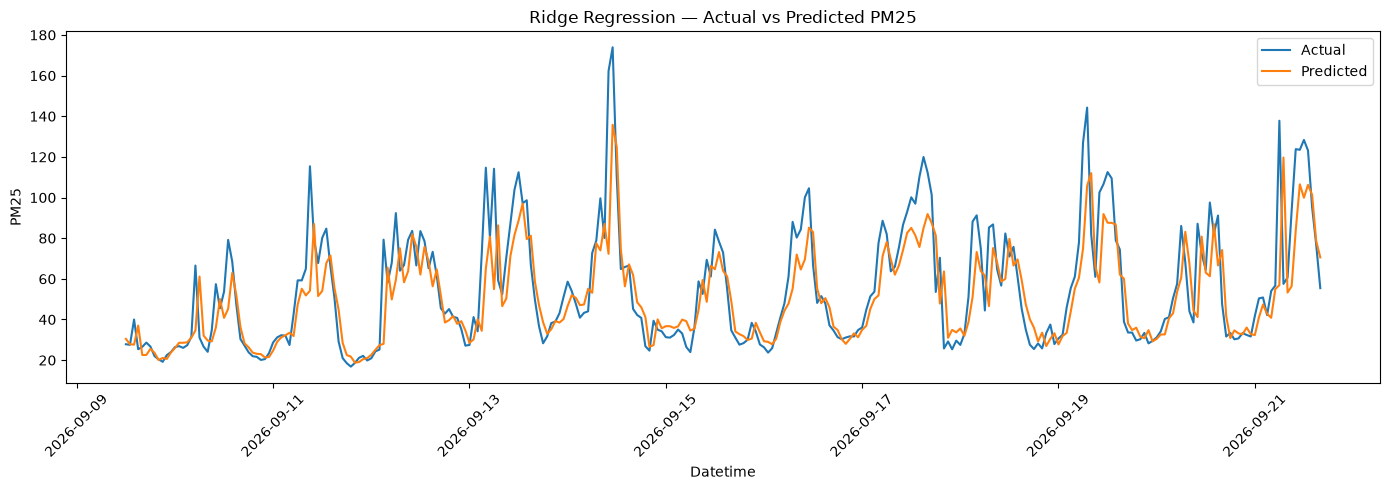

In [72]:
plt.figure(figsize=(14, 5))

plt.plot(
    test["DATETIME_5MIN"],
    y_test,
    label="Actual"
)

plt.plot(
    test["DATETIME_5MIN"],
    y_pred_test,
    label="Predicted"
)

plt.xlabel("Datetime")
plt.ylabel("PM25")
plt.title("Ridge Regression — Actual vs Predicted PM25")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": ridge.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = (
    coef_df
    .sort_values("Abs_Coefficient", ascending=False)
    .reset_index(drop=True)
)

coef_df

,Feature,Coefficient,Abs_Coefficient
0,PM25_roll_mean_3,17.398282,17.398282
1,PM25_lag_1,-6.978872,6.978872
2,PM25_lag_2,-6.460043,6.460043
3,PM10,4.871610,4.871610
4,hour_sin,2.831235,2.831235
5,PM25_lag_24,1.396558,1.396558
6,TMP,0.978093,0.978093
7,PM25_lag_6,0.795897,0.795897
8,WD_sin,-0.583500,0.583500
9,SO2,-0.549994,0.549994


In [74]:
from sklearn.pipeline import Pipeline

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

y_pred_pipeline = ridge_pipeline.predict(X_test)

mae_pipeline = mean_absolute_error(y_test, y_pred_pipeline)
rmse_pipeline = np.sqrt(mean_squared_error(y_test, y_pred_pipeline))
r2_pipeline = r2_score(y_test, y_pred_pipeline)

print("Ridge Pipeline — Test")
print(f"MAE  : {mae_pipeline:.4f}")
print(f"RMSE : {rmse_pipeline:.4f}")
print(f"R²   : {r2_pipeline:.4f}")

Ridge Pipeline — Test
MAE  : 11.4198
RMSE : 17.4967
R²   : 0.6457


In [75]:
import joblib
import os

model_path = "../models/ridge_pm25_forecasting.joblib"

joblib.dump(ridge_pipeline, model_path)

print("Model berhasil disimpan.")
print("Lokasi:", os.path.abspath(model_path))

Model berhasil disimpan.
Lokasi: d:\Kuliah\KP\forecast-ispu\models\ridge_pm25_forecasting.joblib


In [76]:
loaded_model = joblib.load("../models/ridge_pm25_forecasting.joblib")

y_pred_loaded = loaded_model.predict(X_test)

print("Model berhasil di-load kembali.")
print("Jumlah prediksi:", len(y_pred_loaded))

print("\nPerbedaan maksimum dengan prediksi sebelumnya:")
print(np.max(np.abs(y_pred_loaded - y_pred_pipeline)))

Model berhasil di-load kembali.
Jumlah prediksi: 293

Perbedaan maksimum dengan prediksi sebelumnya:
0.0


In [77]:
import pickle

pkl_path = "../models/ridge_pm25_forecasting.pkl"

with open(pkl_path, "wb") as f:
    pickle.dump(ridge_pipeline, f)

print("Model .pkl berhasil disimpan.")
print("Lokasi:", os.path.abspath(pkl_path))

Model .pkl berhasil disimpan.
Lokasi: d:\Kuliah\KP\forecast-ispu\models\ridge_pm25_forecasting.pkl
